A model for analyzing a series, which is the sum of a deterministic *trend* series and a stationary *noise* series, is the so called **[random walk](https://en.wikipedia.org/wiki/Random_walk) with drift model**, given by

$$y_t = \delta+y_{t-1}+w_t,$$

for $t = 1, 2,...$, with initial condition $y_0 = 0$, where $w_t$ is white noise. The constant $\delta$ is called the drift, and if $\delta = 0$, then it is simply called *random walk*.

The equation from above may be rewritten as

$$y_t = \delta t + \sum_{j=1}^t w_j\text{,}$$

for $t = 1,2,...$.

If $\delta = 0$, the value of the time series at time $t$ is equal to the value of the series at time $t-1$ plus a completely random movement determined by $w_t$. 

$$\Delta y_t = y_t-y_{t-1} = w_t$$

The $w_{t}$ values can be interpreted as independent “shocks” which perturb the current state $y_t$ in the amount of $w_{t}$ to produce a new state $y_{t+1}$.

The graph below shows a random walk and a random walk generated with Python:

In [1]:
%load_ext lab_black

In [2]:
import random
import matplotlib.pyplot as plt
import numpy as np

C:\Users\mceck\miniconda3\envs\rasterdata\lib\site-packages\numpy\core\shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


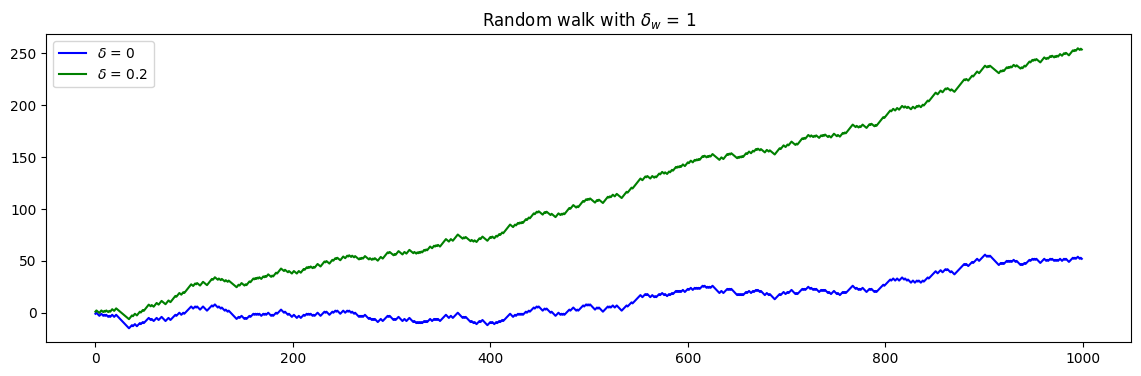

In [3]:
random.seed(1)

random_walk = list()
random_walk_d = list()
random_walk.append(-1 if random.random() < 0.5 else 1)

random_walk_d.append(-1 if random.random() < 0.5 else 1)

for i in range(1, 1000):
    movement = -1 if random.random() < 0.5 else 1
    value = random_walk[i - 1] + movement

    random_walk.append(value)

    ## random walk with drift
    movement_d = movement + 0.2
    value_d = random_walk_d[i - 1] + np.cumsum(movement_d)
    random_walk_d.append(value_d)


# ## Plot
plt.figure(figsize=(14, 4))
plt.plot(random_walk, color="blue", label="$\u03B4$ = 0")
plt.plot(random_walk_d, color="green", label="$\u03B4$ = 0.2")

plt.title("Random walk with $\u03B4_w$ = 1")
plt.legend()
plt.show()



The autocorrelation function of this model type shows typically a very slow decay. 


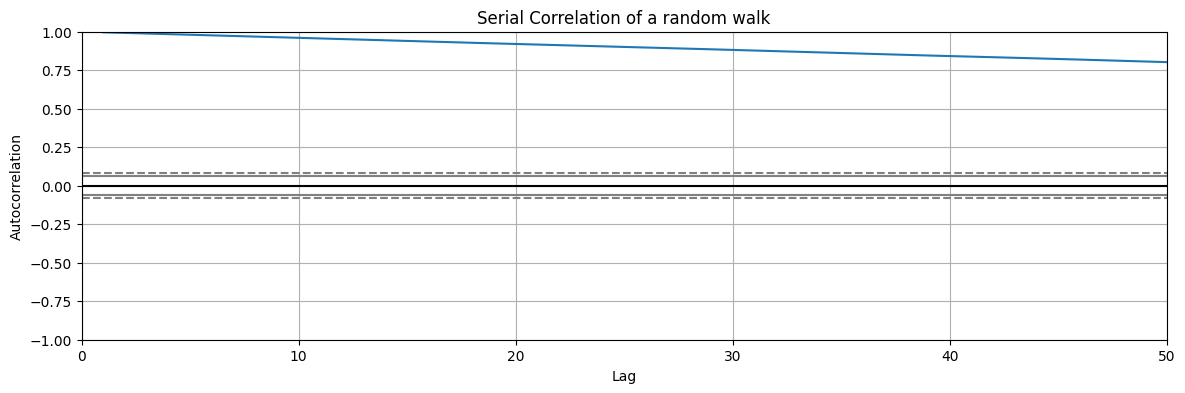

In [4]:
# autocorrelation
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(14, 4))
autocorrelation_plot(random_walk)
plt.axis([0, 50, -1, 1])
plt.title("Serial Correlation of a random walk")

plt.show()

C:\Users\mceck\miniconda3\envs\rasterdata\lib\site-packages\pandas\plotting\_matplotlib\misc.py:451: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  data = np.asarray(series)


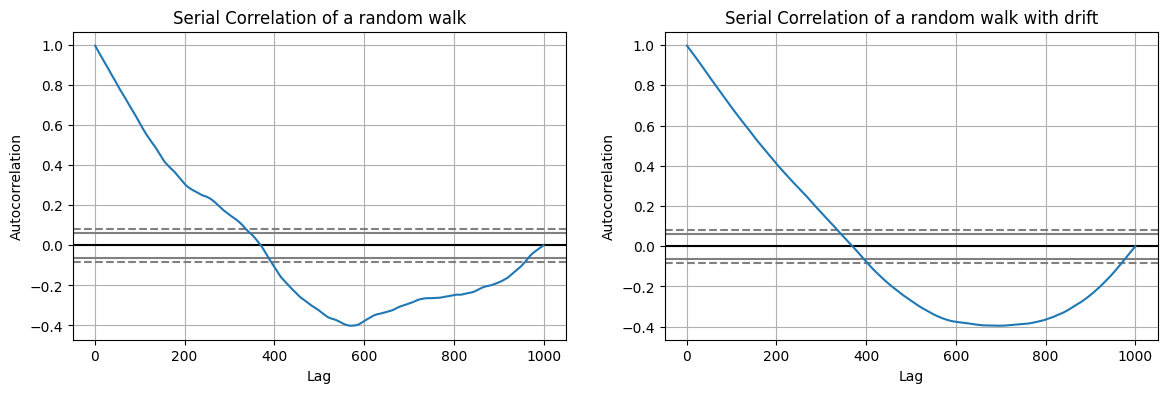

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

autocorrelation_plot(random_walk, ax=ax[0])
ax[0].set_title("Serial Correlation of a random walk")

autocorrelation_plot(random_walk_d, ax=ax[1])
ax[1].set_title("Serial Correlation of a random walk with drift")

plt.show()

Running the example, we generally see the expected trend, in this case across the first few hundred lag observations.


In [1]:
import urllib.request

fp = urllib.request.urlopen("https://userpage.fu-berlin.de/soga/soga-py/citation/citation_py.html")
mybytes = fp.read()

citation = mybytes.decode("utf8")
fp.close()

from IPython.display import display, HTML
display(HTML(citation))